In [1]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import pickle

In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [3]:
# LOAD DATASET

data = pd.read_csv(r'C:\Users\GROVEER\Resume Analaysis Project\Resume.csv')
data = data[['Resume_str', 'Category']].copy()

In [4]:
data.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [5]:
data.shape

(2484, 2)

In [6]:
data['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [7]:
## loading datasets into pandas dataframes

data = pd.read_csv(r'C:\Users\GROVEER\Resume Analaysis Project\Resume.csv')

In [8]:
data = data[['Resume_str', 'Category']]

In [9]:
data.head

<bound method NDFrame.head of                                              Resume_str  Category
0              HR ADMINISTRATOR/MARKETING ASSOCIATE\...        HR
1              HR SPECIALIST, US HR OPERATIONS      ...        HR
2              HR DIRECTOR       Summary      Over 2...        HR
3              HR SPECIALIST       Summary    Dedica...        HR
4              HR MANAGER         Skill Highlights  ...        HR
...                                                 ...       ...
2479           RANK: SGT/E-5 NON- COMMISSIONED OFFIC...  AVIATION
2480           GOVERNMENT RELATIONS, COMMUNICATIONS ...  AVIATION
2481           GEEK SQUAD AGENT         Professional...  AVIATION
2482           PROGRAM DIRECTOR / OFFICE MANAGER    ...  AVIATION
2483           STOREKEEPER II       Professional Sum...  AVIATION

[2484 rows x 2 columns]>

In [10]:
data.shape

(2484, 2)

In [11]:
data['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

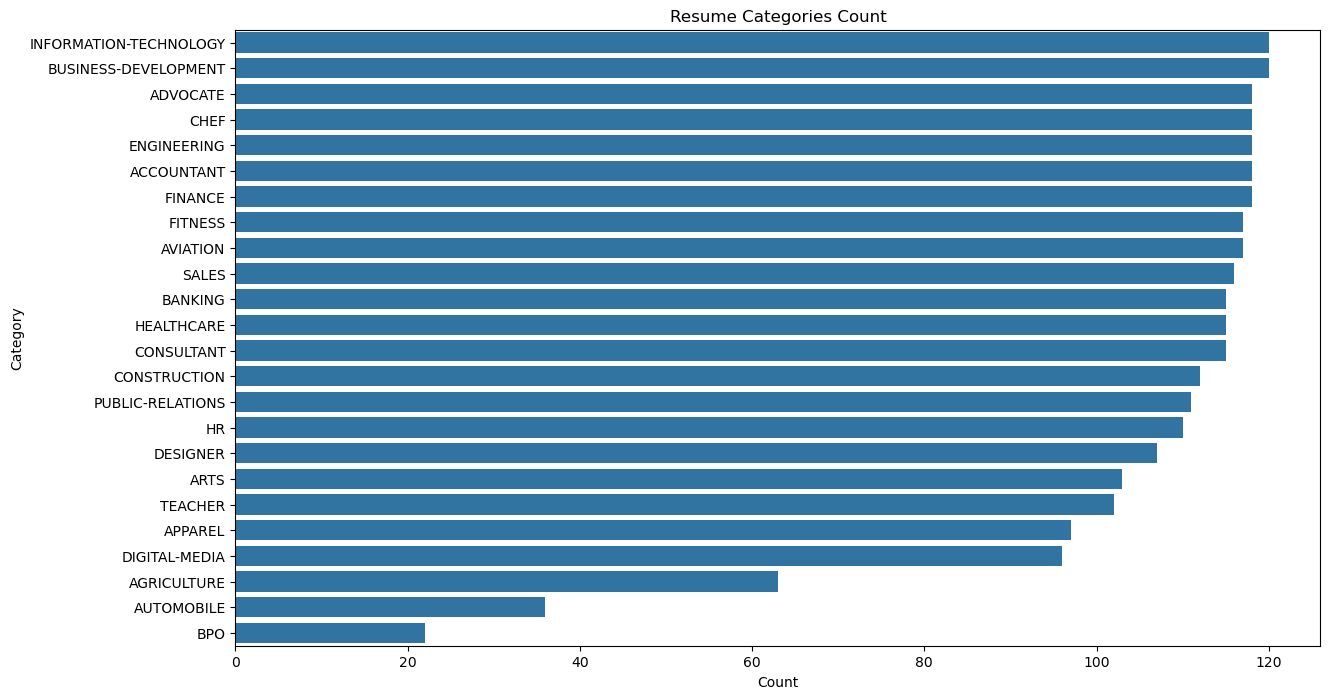

In [12]:
# VISUALIZE DATASET - BAR GRAPH

plt.figure(figsize=(14, 8))
sns.countplot(y=data['Category'], order=data['Category'].value_counts().index)
plt.title("Resume Categories Count")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

In [13]:
data['Category'].unique()

array(['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
       'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
       'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'],
      dtype=object)

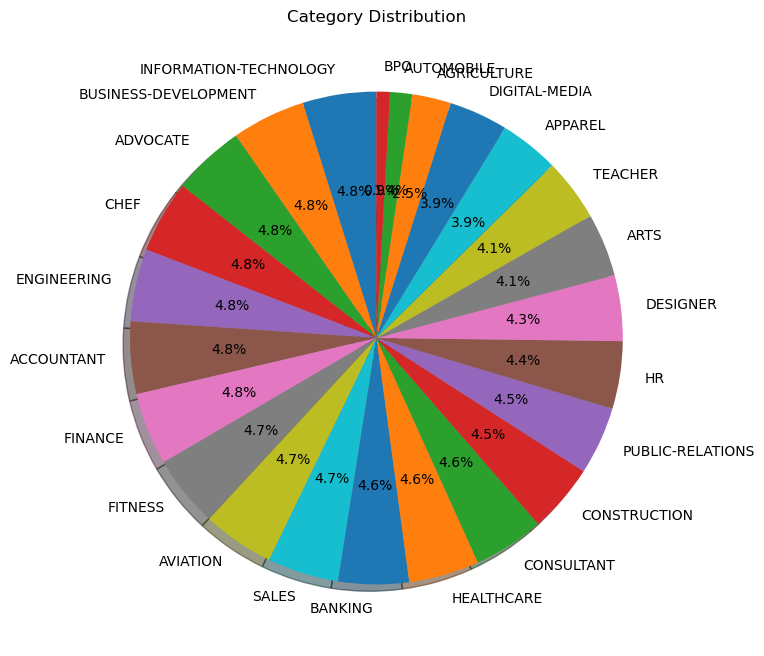

In [14]:
# VISUALIZE DATASET - PIE CHART
counts = data['Category'].value_counts()
labels = counts.index

plt.figure(figsize=(15, 8))

plt.pie(counts,labels=labels, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title("Category Distribution")
plt.show()

In [15]:
# CHECK SAMPLE RESUME

print(data['Category'][160])

DESIGNER


In [16]:
print(data['Resume_str'][160])

         FLORAL DESIGNER       Summary     Personable Customer Service Associate dedicated to providing the highest level of customer service. Outgoing, and efficient with the capacity to multi-task.        Highlights          Inventory control   Employee scheduling  Cash handling and banking      Floral designer  Organized  Placing orders in person and over the phone  Customer service  Excellent multi-tasker            Experience     June 2013   to   March 2016     Company Name   City  ,   State     Floral designer       Designed arrangements for wide range of events, which included wedding and corporate parties. I did all of the prep work as well. I kept the showroom clean and maintained properly for display        January 2011   to   December 2012     Company Name   City  ,   State     Floral designer       Opened and closed the store, which included counting cash drawers and making bank deposits. Helped customers select products that best fit their personal needs, as well as floral

# CLEAN TEXT FUNCTION

In [17]:
def cleanResume(txt):
    txt = str(txt).lower()
    txt = re.sub(r'http\S+', ' ', txt)                  # remove URLs
    txt = re.sub(r'@\S+', ' ', txt)                     # remove mentions
    txt = re.sub(r'#\S+', ' ', txt)                     # remove hashtags
    txt = re.sub(r'rt|cc', ' ', txt)                    # remove RT/cc
    txt = re.sub(r'[^\x00-\x7f]', ' ', txt)             # remove non-ascii
    txt = re.sub(r'[^a-zA-Z\s]', ' ', txt)              # remove punctuation/numbers
    txt = re.sub(r'\s+', ' ', txt).strip()              # remove extra spaces
    return txt

In [18]:
data['cleaned_resume'] = data['Resume_str'].apply(cleanResume)

In [19]:
print(cleanResume("this #### is my Website saichandra and access @gmail.com"))

this is my website saichandra and a ess


In [20]:
# OPTIONAL: FILTER SMALL CLASSES

min_samples = 80
valid_categories = data['Category'].value_counts()
valid_categories = valid_categories[valid_categories >= min_samples].index
data = data[data['Category'].isin(valid_categories)].copy()

print("\nRemaining categories after filtering:")
print(data['Category'].value_counts())


Remaining categories after filtering:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
FINANCE                   118
CHEF                      118
ACCOUNTANT                118
ENGINEERING               118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
BANKING                   115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
Name: count, dtype: int64


# LABEL ENCODING

In [21]:
le = LabelEncoder()
y = le.fit_transform(data['Category'])

In [22]:
print("\nLabel classes:")
print(le.classes_)


Label classes:
['ACCOUNTANT' 'ADVOCATE' 'APPAREL' 'ARTS' 'AVIATION' 'BANKING'
 'BUSINESS-DEVELOPMENT' 'CHEF' 'CONSTRUCTION' 'CONSULTANT' 'DESIGNER'
 'DIGITAL-MEDIA' 'ENGINEERING' 'FINANCE' 'FITNESS' 'HEALTHCARE' 'HR'
 'INFORMATION-TECHNOLOGY' 'PUBLIC-RELATIONS' 'SALES' 'TEACHER']


# TF-IDF VECTORIZATION

In [23]:
tfidf = TfidfVectorizer(stop_words='english',max_features=5000,ngram_range=(1, 2))

In [24]:
X = tfidf.fit_transform(data['cleaned_resume'])

# TRAIN TEST SPLIT

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# MODEL TRAINING

LogisticRegression

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6955602536997886


Support Vector Machine

In [27]:
model = LinearSVC()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.7568710359408034

Classification Report:

                        precision    recall  f1-score   support

            ACCOUNTANT       0.81      0.88      0.84        24
              ADVOCATE       0.68      0.71      0.69        24
               APPAREL       0.80      0.63      0.71        19
                  ARTS       0.43      0.43      0.43        21
              AVIATION       0.88      0.92      0.90        24
               BANKING       0.87      0.87      0.87        23
  BUSINESS-DEVELOPMENT       0.90      0.75      0.82        24
                  CHEF       0.87      0.83      0.85        24
          CONSTRUCTION       0.78      0.82      0.80        22
            CONSULTANT       0.77      0.43      0.56        23
              DESIGNER       0.94      0.81      0.87        21
         DIGITAL-MEDIA       0.62      0.79      0.70        19
           ENGINEERING       0.88      0.88      0.88        24
               FINANCE       0.90      0.79     

# SAVE MODEL FILES

In [28]:
pickle.dump(model, open('clf.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf.pkl', 'wb'))
pickle.dump(le, open('label_encoder.pkl', 'wb'))

In [29]:
print("\nModel, TF-IDF, and Label Encoder saved successfully")
print("Saved label classes:", le.classes_)


Model, TF-IDF, and Label Encoder saved successfully
Saved label classes: ['ACCOUNTANT' 'ADVOCATE' 'APPAREL' 'ARTS' 'AVIATION' 'BANKING'
 'BUSINESS-DEVELOPMENT' 'CHEF' 'CONSTRUCTION' 'CONSULTANT' 'DESIGNER'
 'DIGITAL-MEDIA' 'ENGINEERING' 'FINANCE' 'FITNESS' 'HEALTHCARE' 'HR'
 'INFORMATION-TECHNOLOGY' 'PUBLIC-RELATIONS' 'SALES' 'TEACHER']


# PREDICTION

SINGLE RESUME PREDICTION

In [30]:
Resume = """FLORAL DESIGNER Summary Personable Customer Service Associate dedicated to providing the highest level of customer service Outgoing and efficient with the capacity to multi task Highlights Inventory control Employee scheduling Cash handling and banking Floral designer Organized Placing orders in person and over the phone Customer service Excellent multi tasker Experience June 2013 to March 2016 Company Name City State Floral designer Designed arrangements for wide range of events which included wedding and corporate parties I did all of the prep work as well I kept the showroom clean and maintained properly for display January 2011 to December 2012 Company Name City State Floral designer Opened and closed the store which included counting cash drawers and making bank deposits Helped customers select products that best fit their personal needs as well as floral designing April 2008 to August 2009 Company Name City State Cashier Cashier main function In addition helped unloaded trucks stocked shelves and carried merchandise out on the floor for customers Marked clearance products with updated price tags October 2002 to April 2008 Company Name City State Manager Floral designer Opened and closed the store which included counting cash drawers and making bank deposits Maintained visually appealing and effective displays for the entire store Answered customers questions and addressed problems and complaints in person and via phone Helped customers select products that best fit their personal needs as well as design floral arrangements for the cooler display and for outgoing orders Education Northwestern College City State Dupage Medical Assistant"""

In [31]:
cleaned_resume = cleanResume(Resume)
resume_vector = tfidf.transform([cleaned_resume])
pred_id = model.predict(resume_vector)[0]
predicted_category = le.inverse_transform([pred_id])[0]

In [32]:
print("\nPredicted Category for single resume:", predicted_category)


Predicted Category for single resume: DESIGNER


In [33]:
# SKILLS EXTRACTION

skills_list = [
    'python', 'java', 'sql', 'machine learning', 'flask', 'django',
    'excel', 'communication', 'teaching', 'recruitment',
    'html', 'css', 'javascript', 'data analysis'
]

def extract_skills(text):
    text = text.lower()
    found = [skill for skill in skills_list if skill in text]
    return ', '.join(found) if found else 'No skills found'

In [34]:
# EXPERIENCE EXTRACTION

def extract_experience(text):
    text = text.lower()
    match = re.search(r'(\d+)\+?\s+years', text)
    if match:
        return int(match.group(1))
    return 0


In [35]:
# APPLY ON WHOLE DATASET

data['predicted_category'] = le.inverse_transform(model.predict(X))
data['skills'] = data['cleaned_resume'].apply(extract_skills)
data['experience'] = data['cleaned_resume'].apply(extract_experience)

data.to_csv("processed_resumes.csv", index=False)
print("\nProcessed file saved successfully")

print("\nSample output:")
print(data[['Category', 'predicted_category', 'skills', 'experience']].head())


Processed file saved successfully

Sample output:
  Category predicted_category                      skills  experience
0       HR                 HR               data analysis           0
1       HR                 HR  communication, recruitment           0
2       HR                 HR          excel, recruitment           0
3       HR                 HR        excel, communication           0
4       HR                 HR          excel, recruitment           0
